# GRU: Probabilistic SLA Forecasting — Indian Ocean

**Architecture:** GRU | **Losses:** Quantile + Tube (with recalibration)  
**Metrics:** PICP, MPIW, Winkler Interval Score (WIS)  
**5 locations** | **2021-2023 daily** | **80/20 split** | **5 seeds**  
**Env:** Set `RUN_ENV='local'` for VS Code / lab PC, `'colab'` for Google Colab

In [1]:
# ── Cell 1: Environment + Imports ────────────────────────────
# ┌──────────────────────────────────────────────────────────┐
# │  SET RUN_ENV BEFORE RUNNING                              │
# │  'colab' → mounts Google Drive automatically             │
# │  'local' → uses BASE_DIR path below (VS Code / lab PC)   │
# └──────────────────────────────────────────────────────────┘
RUN_ENV  = 'local'                        # <── change to 'colab' if on Colab
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files'               # <── change to your local folder path
#   on Linux/Mac:  BASE_DIR = '/home/yourname/BMP_Data/'
#   on Colab:      BASE_DIR is set automatically below

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
from scipy.stats import norm as scipy_norm

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

if RUN_ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

DATA_FILE = os.path.join(BASE_DIR, 'sla_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_IndianOcean/')
os.makedirs(SAVE_DIR, exist_ok=True)

ARCH = 'GRU'
print(f'TF {tf.__version__} | Arch: {ARCH} | Env: {RUN_ENV}')
print(f'Data: {DATA_FILE}')
print(f'Save: {SAVE_DIR}')

TF 2.21.0 | Arch: GRU | Env: local
Data: c:\Users\DA IICT K\Desktop\BMP_files\sla_daily_indian_ocean_2021_2023.nc
Save: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/


Loading dataset...
Period: 2021-01-01 to 2023-12-31 (1095 days)

Location check:
  Arabian_Sea        ( 15.0N, 65.0E) | NaN=0.0% | range=[-0.0610,0.2493]m
  Bay_of_Bengal      ( 12.0N, 87.0E) | NaN=0.0% | range=[-0.0308,0.2734]m
  Andaman_Sea        ( 11.0N, 95.0E) | NaN=0.0% | range=[-0.0752,0.2427]m
  Lakshadweep        ( 10.0N, 73.0E) | NaN=0.0% | range=[-0.0808,0.3152]m
  South_IO           ( -5.0N, 75.0E) | NaN=0.0% | range=[-0.0814,0.3201]m


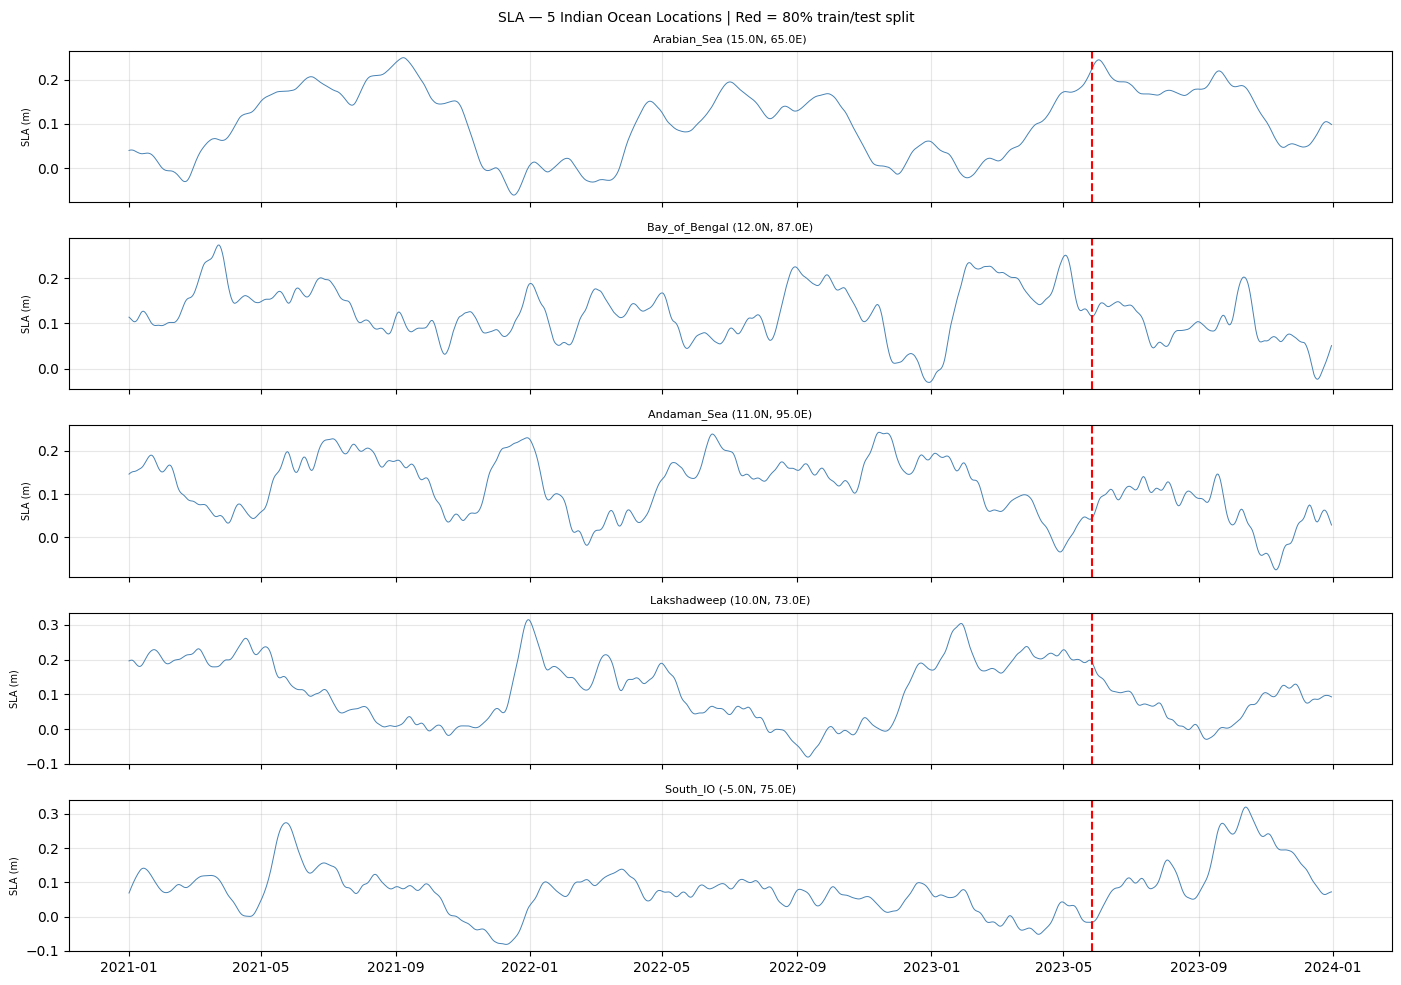

In [2]:
# ── Cell 2: Load Data + Define 5 Locations ───────────────────
LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),   # Central Arabian Sea — high cyclone activity
    'Bay_of_Bengal': (12.0, 87.0),   # Central BoB — strong monsoon-driven SLA
    'Andaman_Sea':   (11.0, 95.0),   # Andaman Sea (specified by sir)
    'Lakshadweep':   (10.0, 73.0),   # Lakshadweep Sea — west coast India
    'South_IO':      (-5.0, 75.0),   # South Indian Ocean — open ocean baseline
}

print('Loading dataset...')
ds = xr.open_dataset(DATA_FILE)
times_index = pd.to_datetime(ds['time'].values)
print(f'Period: {times_index[0].date()} to {times_index[-1].date()} ({len(times_index)} days)')

print('\nLocation check:')
for loc, (lat, lon) in LOCATIONS.items():
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    nan_pct = np.isnan(sla).mean() * 100
    print(f'  {loc:<18} ({lat:5.1f}N,{lon:5.1f}E) | NaN={nan_pct:.1f}% | '
          f'range=[{np.nanmin(sla):.4f},{np.nanmax(sla):.4f}]m')

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
for ax, (loc, (lat, lon)) in zip(axes, LOCATIONS.items()):
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    ax.plot(times_index, sla, lw=0.7, color='steelblue')
    ax.axvline(times_index[int(len(sla)*0.80)], color='red', lw=1.5, ls='--')
    ax.set_title(f'{loc} ({lat}N, {lon}E)', fontsize=8); ax.set_ylabel('SLA (m)', fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle('SLA — 5 Indian Ocean Locations | Red = 80% train/test split', fontsize=10)
plt.tight_layout(); plt.show()

In [4]:
# ── Cell 3: Config + All Helpers ─────────────────────────────
TRAIN_SPLIT  = 0.80
SEQ_LEN      = 30
EPOCHS       = 100
BATCH_SIZE   = 64
LR           = 0.001
PATIENCE     = 20
VAL_SPLIT    = 0.10
SEEDS        = [42, 7, 13, 99, 2025]
TUBE_R       = 0.5
TUBE_DELTA   = 0.01     # default; recalibration in Cell 5 may change this per location
MIN_WIDTH    = 0.005    # metres — minimum interval floor
DROPOUT      = 0.2
TARGET_PICP  = 95.0     # professor's target coverage
ALPHA_WIS    = 0.05     # Winkler score: alpha = 1 - (q_hi - q_lo) = 1 - 0.80 = 0.20

print(f'SEQ_LEN={SEQ_LEN} | EPOCHS={EPOCHS} | BATCH={BATCH_SIZE} | {len(SEEDS)} seeds')
print(f'Tube: r={TUBE_R}, delta={TUBE_DELTA} | Target PICP={TARGET_PICP}%')
n_approx = int(len(times_index)*TRAIN_SPLIT)
print(f'Approx train seqs/location: {n_approx - SEQ_LEN} | test pts: {len(times_index)-n_approx}')

# ─── Sequence builder ─────────────────────────────────────────
def make_sequences(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i : i+seq_len])
        y.append(series[i+seq_len])
    return np.array(X)[..., np.newaxis], np.array(y)

# ─── Loss functions ───────────────────────────────────────────
def build_quantile_loss(scaler, q_lo=0.10, q_hi=0.90):
    min_ws = float(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0])
    def loss(y_true, y_pred):
        true = y_true[:, 0:1]
        lo, hi = y_pred[:, 0:1], y_pred[:, 1:2]
        e_lo, e_hi = true-lo, true-hi
        pin_lo = tf.reduce_mean(tf.maximum(q_lo*e_lo, (q_lo-1)*e_lo))
        pin_hi = tf.reduce_mean(tf.maximum(q_hi*e_hi, (q_hi-1)*e_hi))
        cross  = tf.reduce_mean(tf.nn.relu(lo-hi))
        wd     = tf.reduce_mean(tf.nn.relu(min_ws - (hi-lo)))
        return pin_lo + pin_hi + cross + wd
    return loss

def build_tube_loss(scaler, r=TUBE_R, delta=TUBE_DELTA):
    """Tube Loss — https://github.com/ltpritamanand/Tube_loss"""
    min_ws = float(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0])
    def loss(y_true, y_pred):
        true = y_true[:, 0:1]
        lo, hi = y_pred[:, 0:1], y_pred[:, 1:2]
        below = (1.0-r) * tf.nn.relu(lo-true)
        above = r        * tf.nn.relu(true-hi)
        width = delta    * tf.abs(hi-lo)
        cross = tf.nn.relu(lo-hi)
        wd    = tf.reduce_mean(tf.nn.relu(min_ws - (hi-lo)))
        return tf.reduce_mean(below + above + width + cross) + wd
    return loss

# ─── Winkler Interval Score ───────────────────────────────────
def winkler_score(y_true_m, lo_m, hi_m, alpha=ALPHA_WIS):
    """
    Winkler Interval Score — proper scoring rule for prediction intervals.
    Lower WIS = better (rewards narrow intervals that still cover the truth).
    Formula: WIS = width + (2/alpha) * penalty_for_misses
    alpha = 0.20 for p10/p90 intervals (nominal 80% PI)
    """
    width = hi_m - lo_m
    below = (2.0/alpha) * np.maximum(0, lo_m - y_true_m)  # y below lower bound
    above = (2.0/alpha) * np.maximum(0, y_true_m - hi_m)  # y above upper bound
    return float(np.mean(width + below + above))

# ─── Evaluate: PICP + MPIW + WIS, in metres, NaN-guarded ─────
def evaluate(y_true_s, y_pred_raw, scaler):
    lo_m = scaler.inverse_transform(y_pred_raw[:, 0:1]).flatten()
    hi_m = scaler.inverse_transform(y_pred_raw[:, 1:2]).flatten()
    y_m  = scaler.inverse_transform(y_true_s.reshape(-1,1)).flatten()
    if np.any(np.isnan(lo_m)) or np.any(np.isnan(hi_m)):
        return np.nan, np.nan, np.nan, lo_m, hi_m, y_m
    lo = np.minimum(lo_m, hi_m); hi = np.maximum(lo_m, hi_m)
    picp = np.mean((y_m >= lo) & (y_m <= hi)) * 100.0
    mpiw = np.mean(hi - lo)
    wis  = winkler_score(y_m, lo, hi)
    return picp, mpiw, wis, lo, hi, y_m

# ─── Model builder ────────────────────────────────────────────
def build_model(arch=ARCH, seq_len=SEQ_LEN, dropout=DROPOUT):
    inp = keras.Input(shape=(seq_len, 1))
    if arch == 'LSTM':
        x = layers.LSTM(64, activation='tanh')(inp)
    elif arch == 'GRU':
        x = layers.GRU(64, activation='tanh')(inp)
    else:
        x = layers.SimpleRNN(64, activation='tanh')(inp)
    x   = layers.Dropout(dropout)(x)
    x   = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(2, activation='linear')(x)
    return keras.Model(inp, out)

# ─── Train one model (reusable) ───────────────────────────────
def train_one(X_tr, y_tr_dup, loss_fn, seed, epochs=EPOCHS):
    tf.random.set_seed(seed); np.random.seed(seed)
    model = build_model()
    model.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss=loss_fn)
    cbs = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr, y_tr_dup, epochs=epochs, batch_size=BATCH_SIZE,
                     validation_split=VAL_SPLIT, callbacks=cbs, verbose=0)
    return model, len(hist.history['loss'])

print('All helpers defined. Proceed to Cell 4.')

SEQ_LEN=30 | EPOCHS=100 | BATCH=64 | 5 seeds
Tube: r=0.5, delta=0.01 | Target PICP=95.0%
Approx train seqs/location: 846 | test pts: 219
All helpers defined. Proceed to Cell 4.


In [5]:
# ── Cell 4: Main Training Loop ───────────────────────────────
all_results = []
all_preds   = {}   # {loc: {model_id: {seed: (lo,hi,y_m)}}}

for loc_name, (lat, lon) in LOCATIONS.items():
    print(f'\n{"#"*65}')
    print(f'  LOCATION: {loc_name} | {lat}N, {lon}E')
    print(f'{"#"*65}')

    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    sla_series = s.values

    n_total = len(sla_series)
    n_train = int(n_total * TRAIN_SPLIT)
    n_test  = n_total - n_train

    scaler  = RobustScaler()
    train_s = scaler.fit_transform(sla_series[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(sla_series[n_train:].reshape(-1,1)).flatten()

    X_tr, y_tr = make_sequences(train_s, SEQ_LEN)
    combined    = np.concatenate([train_s, test_s])
    X_te = np.array([combined[n_train-SEQ_LEN+i : n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])
    y_tr_dup = np.hstack([y_tr.reshape(-1,1), y_tr.reshape(-1,1)])

    t_period = f'{times_index[0].strftime("%Y-%m")} to {times_index[n_train-1].strftime("%Y-%m")}'
    v_period = f'{times_index[n_train].strftime("%Y-%m")} to {times_index[-1].strftime("%Y-%m")}'
    print(f'  Train seqs: {len(X_tr)} | Test pts: {len(X_te)}')

    loss_configs = [
        ('Quantile', build_quantile_loss(scaler), 0.10, 0.90, None,   None),
        ('Tube',     build_tube_loss(scaler),      None, None, TUBE_R, TUBE_DELTA),
    ]
    all_preds.setdefault(loc_name, {})

    for loss_name, loss_fn, q_lo_v, q_hi_v, r_v, delta_v in loss_configs:
        model_id = f'{ARCH}-{loss_name}'
        all_preds[loc_name][model_id] = {}
        print(f'\n  {"="*55}')
        print(f'  {model_id} @ {loc_name}  (delta={delta_v})')
        print(f'  {"="*55}')

        seed_picps, seed_mpiws, seed_wis = [], [], []

        for seed in SEEDS:
            model, ep = train_one(X_tr, y_tr_dup, loss_fn, seed)
            preds = model.predict(X_te, verbose=0)
            picp, mpiw, wis, lo, hi, y_m = evaluate(y_te, preds, scaler)
            seed_picps.append(picp); seed_mpiws.append(mpiw); seed_wis.append(wis)
            all_preds[loc_name][model_id][seed] = (lo, hi, y_m)
            flag = ' NaN' if np.isnan(picp) else ''
            print(f'    seed={seed:4d} | PICP={picp:5.1f}% | MPIW={mpiw:.4f}m | WIS={wis:.4f} | ep={ep}{flag}')

        avg_picp = np.nanmean(seed_picps); std_picp = np.nanstd(seed_picps)
        avg_mpiw = np.nanmean(seed_mpiws); std_mpiw = np.nanstd(seed_mpiws)
        avg_wis  = np.nanmean(seed_wis);   std_wis  = np.nanstd(seed_wis)
        n_valid  = sum(1 for p in seed_picps if not np.isnan(p))
        print(f'  --> PICP={avg_picp:.1f}+/-{std_picp:.1f}%  MPIW={avg_mpiw:.4f}m  WIS={avg_wis:.4f}  [{n_valid}/{len(SEEDS)}]')

        all_results.append(dict(
            location=loc_name, lat=lat, lon=lon, arch=ARCH,
            loss=loss_name, model=model_id,
            q_lo=q_lo_v, q_hi=q_hi_v, r=r_v, delta=delta_v,
            avg_picp=avg_picp, std_picp=std_picp,
            avg_mpiw=avg_mpiw, std_mpiw=std_mpiw,
            avg_wis=avg_wis,   std_wis=std_wis,
            calibrated=False, n_valid_seeds=n_valid, n_seeds=len(SEEDS),
            n_train_seqs=len(X_tr), n_test_pts=len(X_te),
            train_period=t_period, test_period=v_period, seq_len=SEQ_LEN
        ))

df = pd.DataFrame(all_results)
csv_path = os.path.join(SAVE_DIR, f'results_{ARCH}_IO.csv')
df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')
print(df[['location','model','avg_picp','std_picp','avg_mpiw','avg_wis','n_valid_seeds']].to_string(index=False))


#################################################################
  LOCATION: Arabian_Sea | 15.0N, 65.0E
#################################################################
  Train seqs: 846 | Test pts: 219

  GRU-Quantile @ Arabian_Sea  (delta=None)
    seed=  42 | PICP= 99.5% | MPIW=0.0108m | WIS=0.0108 | ep=100
    seed=   7 | PICP= 98.2% | MPIW=0.0117m | WIS=0.0119 | ep=100
    seed=  13 | PICP= 97.7% | MPIW=0.0116m | WIS=0.0126 | ep=100
    seed=  99 | PICP=100.0% | MPIW=0.0096m | WIS=0.0096 | ep=87
    seed=2025 | PICP= 95.9% | MPIW=0.0105m | WIS=0.0113 | ep=100
  --> PICP=98.3+/-1.5%  MPIW=0.0108m  WIS=0.0113  [5/5]

  GRU-Tube @ Arabian_Sea  (delta=0.01)
    seed=  42 | PICP=100.0% | MPIW=0.0178m | WIS=0.0178 | ep=100
    seed=   7 | PICP=100.0% | MPIW=0.0191m | WIS=0.0191 | ep=100
    seed=  13 | PICP= 97.3% | MPIW=0.0192m | WIS=0.0201 | ep=100
    seed=  99 | PICP=100.0% | MPIW=0.0232m | WIS=0.0232 | ep=100
    seed=2025 | PICP= 99.1% | MPIW=0.0210m | WIS=0.0211 | ep=100
  -->

In [7]:
# ── Cell 5: Recalibration of Tube Loss ───────────────────────
# Goal: for locations where Tube PICP deviates from TARGET_PICP (+/-1%),
# find a better delta using a calibration split, retrain, update results.
#
# Method (no test leakage):
#   Split training data: 90% train_inner + 10% calibration hold-out
#   Sweep delta on calibration hold-out (2 quick seeds)
#   Pick delta closest to TARGET_PICP on calibration set
#   Retrain on full training data with calibrated delta (5 seeds)
#   Update df and CSV

CALIB_FRAC   = 0.10     # fraction of training data used as calibration set
DELTA_SWEEP  = [0.01, 0.02, 0.03, 0.04, 0.05] # Updated to 0.1 increments as requested
CALIB_SEEDS  = [42, 7]  # 2 seeds for fast sweep (just calibration, not final)
TOLERANCE    = 1.0      # Updated to +/- 1%

print(f'Recalibration target: PICP = {TARGET_PICP}% +/- {TOLERANCE}%')
print(f'Will recalibrate Tube loss for any location outside [{TARGET_PICP-TOLERANCE:.0f}%, {TARGET_PICP+TOLERANCE:.0f}%]')
print(f'Delta sweep: {DELTA_SWEEP}\n')

recalib_results = []

for loc_name, (lat, lon) in LOCATIONS.items():
    # Check current Tube PICP for this location
    mask    = (df['location'] == loc_name) & (df['loss'] == 'Tube')
    cur_row = df[mask]
    if len(cur_row) == 0:
        print(f'{loc_name}: No Tube results found, skipping.')
        continue

    cur_picp = float(cur_row['avg_picp'].values[0])
    cur_delta = float(cur_row['delta'].values[0])

    if abs(cur_picp - TARGET_PICP) <= TOLERANCE:
        print(f'{loc_name}: Tube PICP={cur_picp:.1f}% — within target range, no recalibration needed.')
        continue

    direction = 'too high (increasing delta)' if cur_picp > TARGET_PICP else 'too low (decreasing delta)'
    print(f'{loc_name}: Tube PICP={cur_picp:.1f}% — {direction}')

    # Re-extract data for this location
    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    sla_series = s.values
    n_total = len(sla_series)
    n_train = int(n_total * TRAIN_SPLIT)
    n_test  = n_total - n_train

    scaler  = RobustScaler()
    train_s = scaler.fit_transform(sla_series[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(sla_series[n_train:].reshape(-1,1)).flatten()

    # Split training into inner-train + calibration
    n_calib       = max(SEQ_LEN+10, int(len(train_s) * CALIB_FRAC))
    n_train_inner = len(train_s) - n_calib
    train_inner_s = train_s[:n_train_inner]
    calib_s       = train_s[n_train_inner:]

    X_tr_inner, y_tr_inner = make_sequences(train_inner_s, SEQ_LEN)
    # Calibration sequences use boundary context correctly
    calib_combined = np.concatenate([train_inner_s, calib_s])
    X_calib = np.array([calib_combined[n_train_inner-SEQ_LEN+i : n_train_inner+i]
                        for i in range(len(calib_s))])[..., np.newaxis]
    y_calib = np.array([calib_combined[n_train_inner+i] for i in range(len(calib_s))])
    y_inner_dup = np.hstack([y_tr_inner.reshape(-1,1), y_tr_inner.reshape(-1,1)])

    print(f'  Calibration sweep: {len(X_tr_inner)} inner-train seqs, {len(X_calib)} calib seqs')

    # Sweep delta
    best_delta = cur_delta
    best_diff  = abs(cur_picp - TARGET_PICP)

    print(f'  {"delta":>8}  {"calib_PICP":>12}  {"diff_to_target":>15}')
    print(f'  {"-"*40}')
    for delta_try in DELTA_SWEEP:
        loss_fn = build_tube_loss(scaler, r=TUBE_R, delta=delta_try)
        picps_c = []
        for seed in CALIB_SEEDS:
            model_c, _ = train_one(X_tr_inner, y_inner_dup, loss_fn, seed, epochs=60)
            preds_c = model_c.predict(X_calib, verbose=0)
            picp_c, *_ = evaluate(y_calib, preds_c, scaler)
            if not np.isnan(picp_c): picps_c.append(picp_c)
        if not picps_c: continue
        avg_c = np.mean(picps_c)
        diff  = abs(avg_c - TARGET_PICP)
        marker = ' <-- best' if diff < best_diff else ''
        print(f'  {delta_try:8.3f}  {avg_c:12.1f}%  {diff:15.1f}%{marker}')
        if diff < best_diff:
            best_diff  = diff
            best_delta = delta_try

    print(f'\n  Calibrated delta: {best_delta} (was {cur_delta})')

    # Retrain on FULL training data with calibrated delta
    X_tr_full, y_tr_full = make_sequences(train_s, SEQ_LEN)
    y_tr_full_dup = np.hstack([y_tr_full.reshape(-1,1), y_tr_full.reshape(-1,1)])
    combined = np.concatenate([train_s, test_s])
    X_te = np.array([combined[n_train-SEQ_LEN+i : n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])

    loss_fn_cal = build_tube_loss(scaler, r=TUBE_R, delta=best_delta)
    model_id    = f'{ARCH}-Tube'

    seed_picps, seed_mpiws, seed_wis = [], [], []
    all_preds[loc_name][f'{model_id}-Cal'] = {}

    print(f'  Retraining with delta={best_delta} (5 seeds)...')
    for seed in SEEDS:
        model_c, ep = train_one(X_tr_full, y_tr_full_dup, loss_fn_cal, seed)
        preds = model_c.predict(X_te, verbose=0)
        picp, mpiw, wis, lo, hi, y_m = evaluate(y_te, preds, scaler)
        seed_picps.append(picp); seed_mpiws.append(mpiw); seed_wis.append(wis)
        all_preds[loc_name][f'{model_id}-Cal'][seed] = (lo, hi, y_m)
        flag = ' NaN' if np.isnan(picp) else ''
        print(f'    seed={seed:4d} | PICP={picp:5.1f}% | MPIW={mpiw:.4f}m | WIS={wis:.4f}{flag}')

    avg_picp = np.nanmean(seed_picps); std_picp = np.nanstd(seed_picps)
    avg_mpiw = np.nanmean(seed_mpiws); std_mpiw = np.nanstd(seed_mpiws)
    avg_wis  = np.nanmean(seed_wis);   std_wis  = np.nanstd(seed_wis)
    n_valid  = sum(1 for p in seed_picps if not np.isnan(p))
    print(f'  --> Calibrated: PICP={avg_picp:.1f}+/-{std_picp:.1f}%  MPIW={avg_mpiw:.4f}m  WIS={avg_wis:.4f}')

    t_period = f'{times_index[0].strftime("%Y-%m")} to {times_index[n_train-1].strftime("%Y-%m")}'
    v_period = f'{times_index[n_train].strftime("%Y-%m")} to {times_index[-1].strftime("%Y-%m")}'

    recalib_results.append(dict(
        location=loc_name, lat=lat, lon=lon, arch=ARCH,
        loss='Tube', model=f'{model_id}-Cal',
        q_lo=None, q_hi=None, r=TUBE_R, delta=best_delta,
        avg_picp=avg_picp, std_picp=std_picp,
        avg_mpiw=avg_mpiw, std_mpiw=std_mpiw,
        avg_wis=avg_wis,   std_wis=std_wis,
        calibrated=True, n_valid_seeds=n_valid, n_seeds=len(SEEDS),
        n_train_seqs=len(X_tr_full), n_test_pts=len(X_te),
        train_period=t_period, test_period=v_period, seq_len=SEQ_LEN
    ))

if recalib_results:
    df_cal = pd.DataFrame(recalib_results)
    df = pd.concat([df, df_cal], ignore_index=True)
    df.to_csv(csv_path, index=False)
    print(f'\nRecalibration complete. Updated CSV saved: {csv_path}')
    print('\nComparison (original vs calibrated Tube):')
    tube_rows = df[df['loss']=='Tube'].sort_values(['location','calibrated'])
    print(tube_rows[['location','delta','avg_picp','std_picp','avg_mpiw','avg_wis','calibrated']].to_string(index=False))
else:
    print('\nNo recalibration needed for any location.')

Recalibration target: PICP = 95.0% +/- 1.0%
Will recalibrate Tube loss for any location outside [94%, 96%]
Delta sweep: [0.01, 0.02, 0.03, 0.04, 0.05]

Arabian_Sea: Tube PICP=99.3% — too high (increasing delta)
  Calibration sweep: 759 inner-train seqs, 87 calib seqs
     delta    calib_PICP   diff_to_target
  ----------------------------------------
     0.010         100.0%              5.0%
     0.020         100.0%              5.0%
     0.030          98.3%              3.3% <-- best
     0.040          96.6%              1.6% <-- best
     0.050          92.5%              2.5%

  Calibrated delta: 0.04 (was 0.01)
  Retraining with delta=0.04 (5 seeds)...
    seed=  42 | PICP= 99.1% | MPIW=0.0107m | WIS=0.0108
    seed=   7 | PICP= 98.6% | MPIW=0.0136m | WIS=0.0138
    seed=  13 | PICP=100.0% | MPIW=0.0110m | WIS=0.0110
    seed=  99 | PICP= 98.2% | MPIW=0.0135m | WIS=0.0139
    seed=2025 | PICP= 99.5% | MPIW=0.0129m | WIS=0.0130
  --> Calibrated: PICP=99.1+/-0.6%  MPIW=0.0124m  

Generating plots...


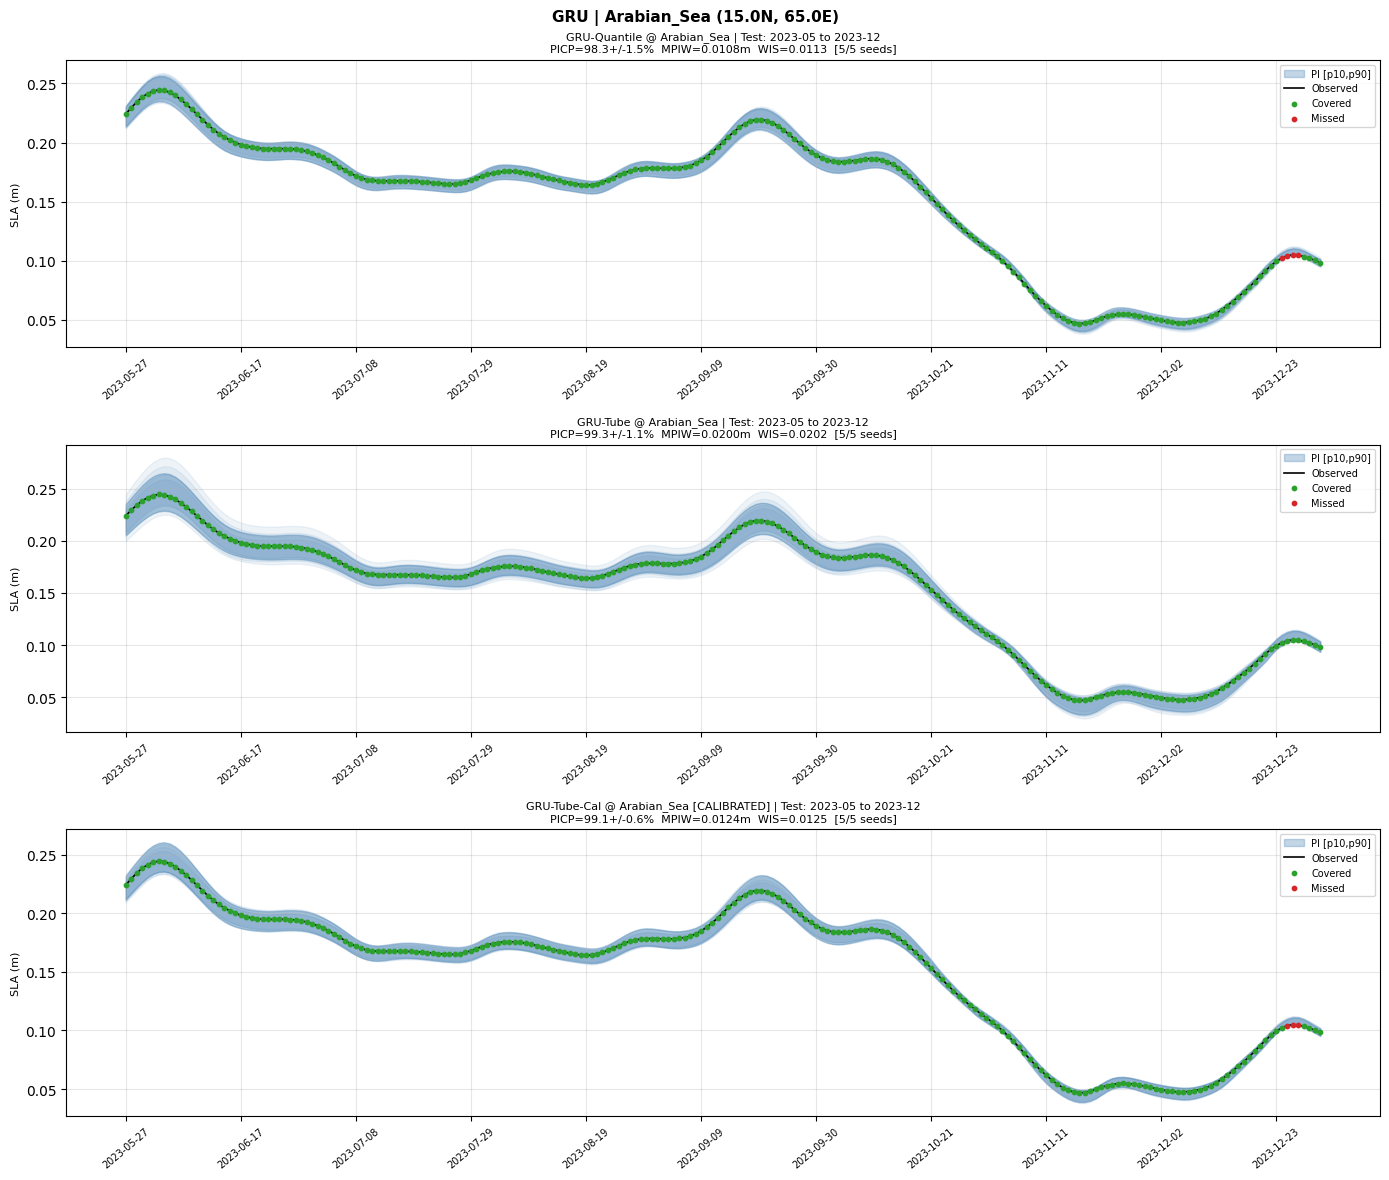

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_GRU_Arabian_Sea.png


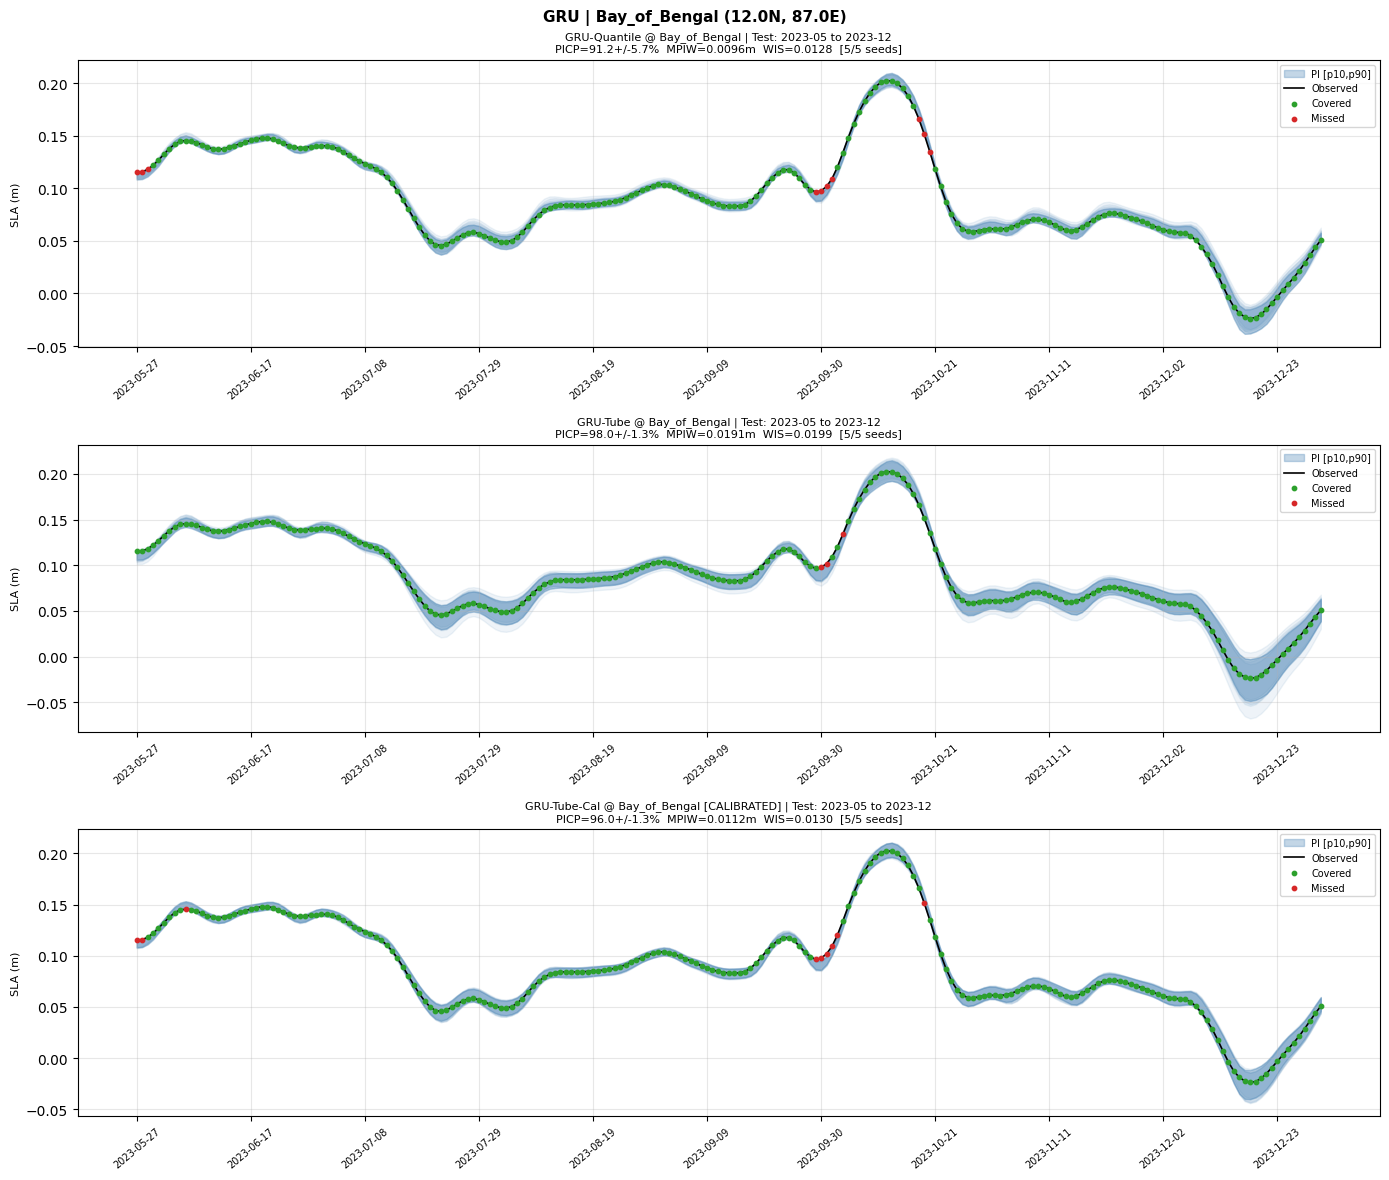

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_GRU_Bay_of_Bengal.png


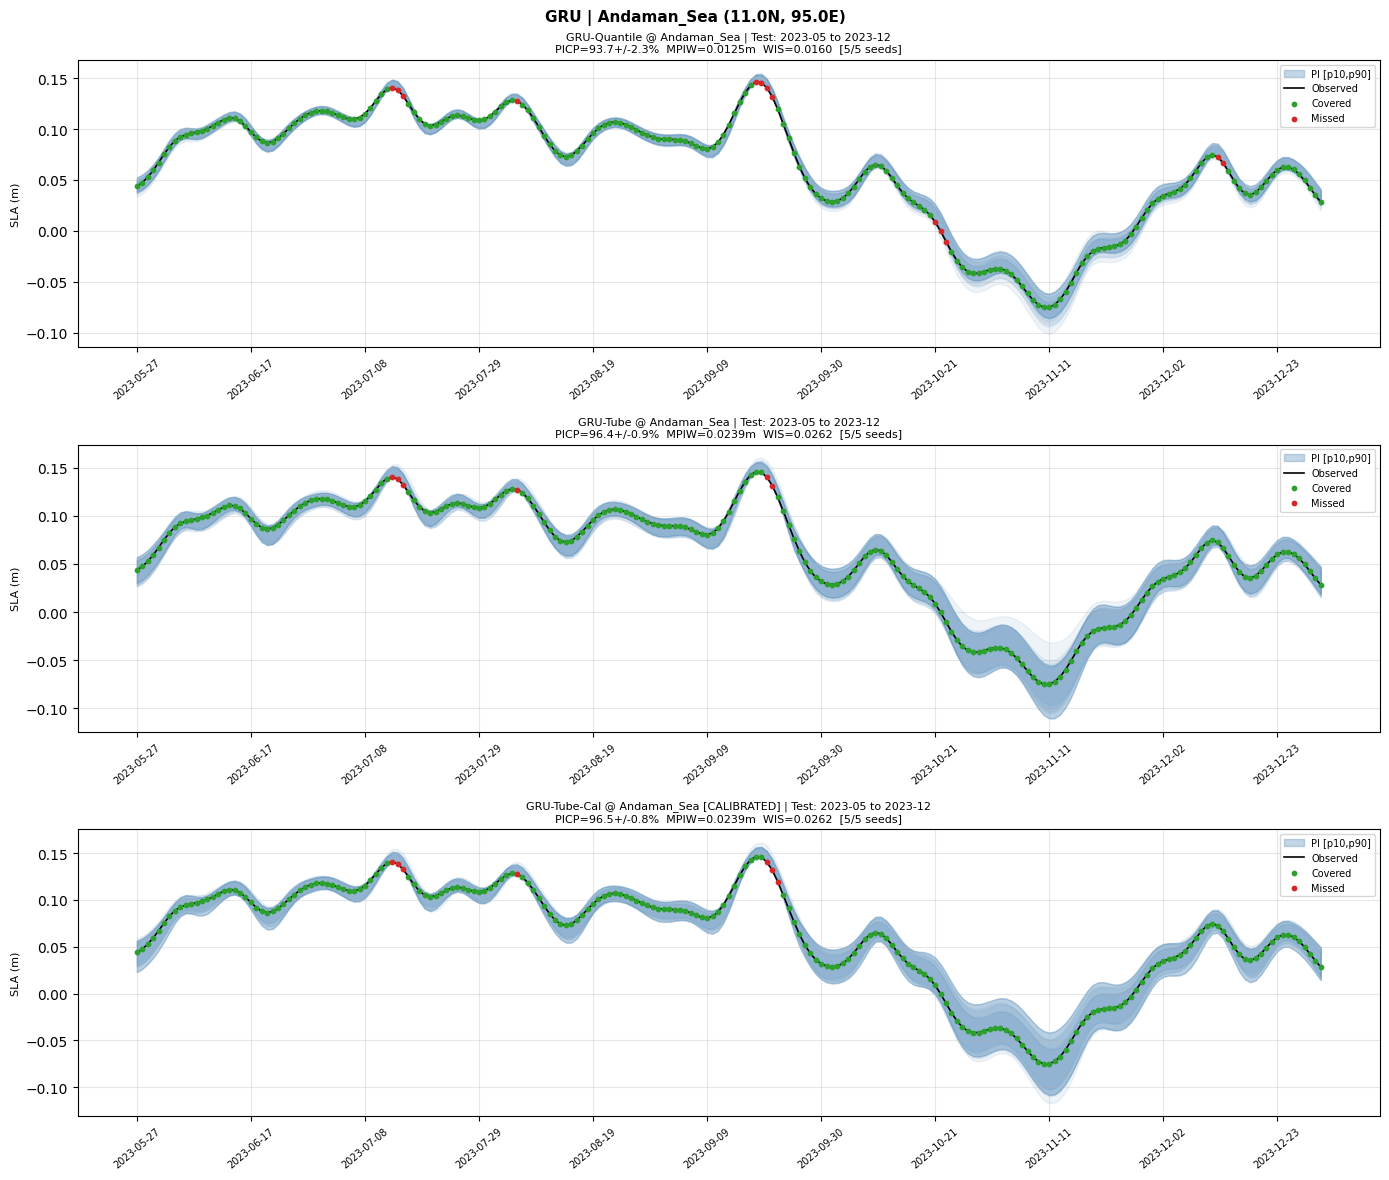

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_GRU_Andaman_Sea.png


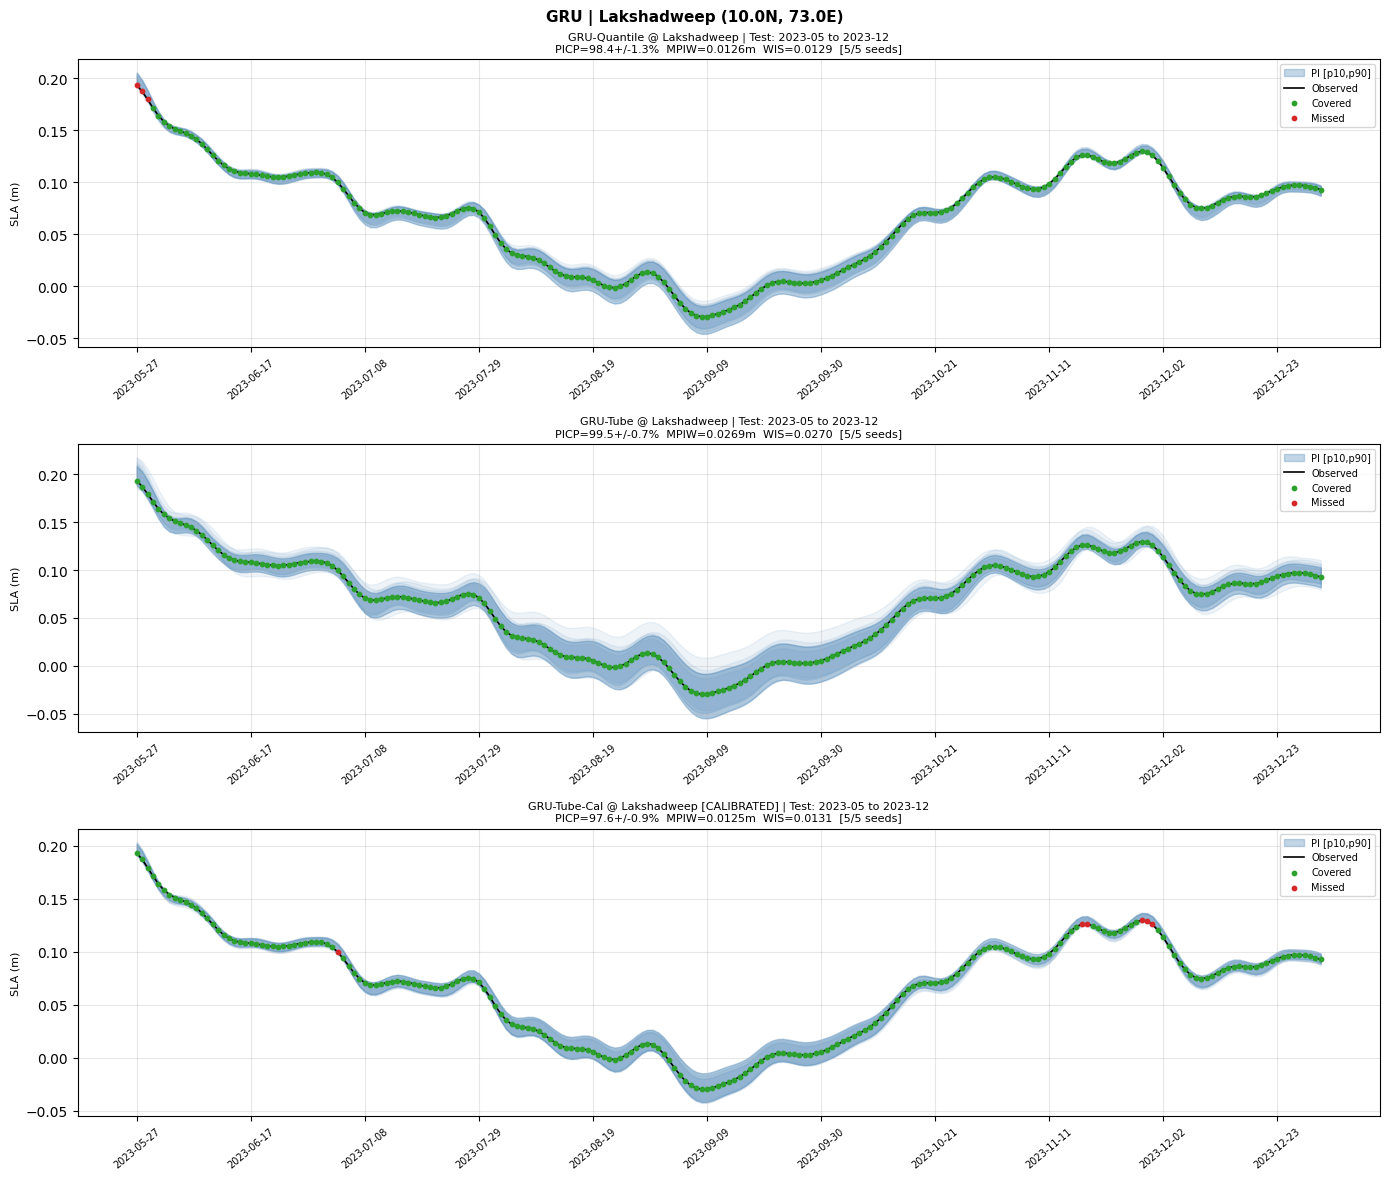

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_GRU_Lakshadweep.png


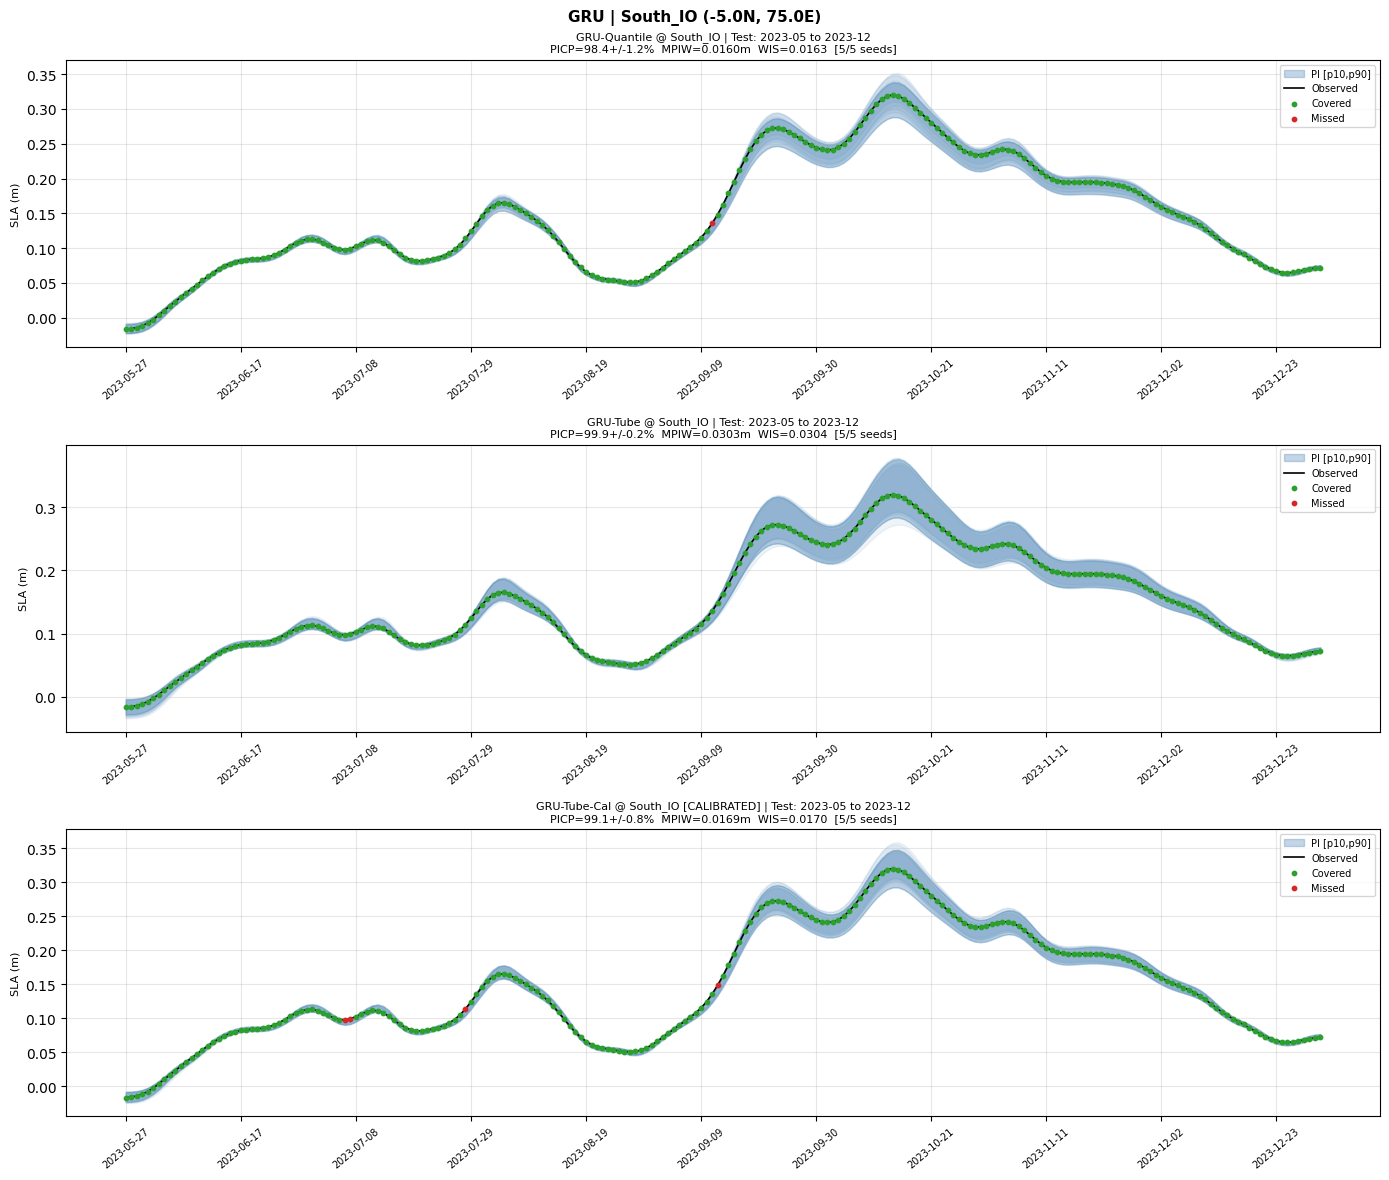

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_GRU_South_IO.png


In [10]:
# ── Cell 6: Visualisation ────────────────────────────────────
print('Generating plots...')

for loc_name, (lat, lon) in LOCATIONS.items():
    sub = df[df['location'] == loc_name]
    model_ids = sub['model'].tolist()
    n_rows = len(model_ids)

    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 4*n_rows))
    if n_rows == 1: axes = [axes]

    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    sla_s   = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    n_train = int(len(sla_s)*TRAIN_SPLIT)
    t_times = times_index[n_train:]
    x_ax    = range(len(t_times))
    step    = max(1, len(t_times)//10)

    for ax, model_id in zip(axes, model_ids):
        row = sub[sub['model']==model_id].iloc[0]
        pd_ = all_preds.get(loc_name, {}).get(model_id, {})
        y_m = None

        for seed, (lo, hi, ym) in pd_.items():
            if y_m is None: y_m = ym
            if np.any(np.isnan(lo)): continue
            ax.fill_between(x_ax, lo, hi, alpha=0.09, color='steelblue')

        cands = [(abs(np.mean((ym >= lo) & (ym <= hi))*100 - row['avg_picp']), seed)
                 for seed in SEEDS if seed in pd_ and not np.any(np.isnan(pd_[seed][0]))]
        if cands:
            best = sorted(cands)[0][1]
            lo_b, hi_b, y_m = pd_[best]
            ax.fill_between(x_ax, lo_b, hi_b, alpha=0.32, color='steelblue', label='PI [p10,p90]')
            covered = (y_m >= lo_b) & (y_m <= hi_b)
            ax.plot(x_ax, y_m, 'k-', lw=1.2, label='Observed')
            ax.scatter(np.where(covered)[0],  y_m[covered],  color='#2ca02c', s=10, zorder=5, label='Covered')
            ax.scatter(np.where(~covered)[0], y_m[~covered], color='#d62728', s=10, zorder=5, label='Missed')

        ax.set_xticks(list(x_ax)[::step])
        ax.set_xticklabels([t_times[i].strftime('%Y-%m-%d') for i in range(0,len(t_times),step)],
                           rotation=40, fontsize=7)
        ax.set_ylabel('SLA (m)', fontsize=8)
        cal_tag = ' [CALIBRATED]' if row.get('calibrated', False) else ''
        ax.set_title(
            f'{model_id} @ {loc_name}{cal_tag} | Test: {row["test_period"]}\n'
            f'PICP={row["avg_picp"]:.1f}+/-{row["std_picp"]:.1f}%  '
            f'MPIW={row["avg_mpiw"]:.4f}m  WIS={row["avg_wis"]:.4f}  '
            f'[{row["n_valid_seeds"]}/{row["n_seeds"]} seeds]', fontsize=8)
        ax.legend(fontsize=7, loc='upper right'); ax.grid(True, alpha=0.3)

    fig.suptitle(f'{ARCH} | {loc_name} ({lat}N, {lon}E)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fp = os.path.join(SAVE_DIR, f'plot_{ARCH}_{loc_name}.png')
    plt.savefig(fp, dpi=110, bbox_inches='tight'); plt.show()
    print(f'  Saved: {fp}')

In [11]:
# ── Cell 7: Per-architecture Summary Table ───────────────────
print(f'\n{"="*100}')
print(f'  {ARCH} -- ALL LOCATIONS (calibrated rows marked *)')
print(f'{"="*100}')
print(f'  {"Location":<18} {"Model":<24} {"PICP%":>7} {"+/-":>5} {"MPIW(m)":>9} {"+/-":>8} '
      f'{"WIS":>8} {"r":>5} {"delta":>7} {"Cal":>4}')
print(f'  {"-"*100}')
for _, r in df.sort_values(["location","model"]).iterrows():
    r_s = f"{r['r']:.1f}"    if pd.notna(r['r'])     else "  --"
    d_s = f"{r['delta']:.3f}" if pd.notna(r['delta']) else "    --"
    w_s = f"{r['avg_wis']:.4f}" if pd.notna(r['avg_wis']) else "      --"
    cal = "  *" if r.get('calibrated', False) else "   "
    print(f'  {r["location"]:<18} {r["model"]:<24} '
          f'{r["avg_picp"]:7.1f} {r["std_picp"]:5.1f} '
          f'{r["avg_mpiw"]:9.4f} {r["std_mpiw"]:8.4f} '
          f'{w_s:>8} {r_s:>5} {d_s:>7} {cal}')


  GRU -- ALL LOCATIONS (calibrated rows marked *)
  Location           Model                      PICP%   +/-   MPIW(m)      +/-      WIS     r   delta  Cal
  ----------------------------------------------------------------------------------------------------
  Andaman_Sea        GRU-Quantile                93.7   2.3    0.0125   0.0004   0.0160    --      --    
  Andaman_Sea        GRU-Tube                    96.4   0.9    0.0239   0.0014   0.0262   0.5   0.010    
  Andaman_Sea        GRU-Tube-Cal                96.5   0.8    0.0239   0.0021   0.0262   0.5   0.010   *
  Arabian_Sea        GRU-Quantile                98.3   1.5    0.0108   0.0008   0.0113    --      --    
  Arabian_Sea        GRU-Tube                    99.3   1.1    0.0200   0.0019   0.0202   0.5   0.010    
  Arabian_Sea        GRU-Tube-Cal                99.1   0.6    0.0124   0.0012   0.0125   0.5   0.040   *
  Bay_of_Bengal      GRU-Quantile                91.2   5.7    0.0096   0.0007   0.0128    --      --  